# Calibration of the Treatment Term

Companion notebook to the growth one. The tool is the same; only the
application and the data change. In the control notebook, we compared seven
*growth laws*. Here, growth is **fixed** (using the law and parameters chosen
from the control fit), and we calibrate the **treatment term**.

There are several possible forms for the treatment term. This notebook develops
**one of them in detail — exponential decay (ED)** — and, from it,
shows the **recipe for building the others** (Section 7.1). The idea is to
master the pattern with one example and then replicate it for each function on
the list to be tested.

## Core idea

The model has the form

$$\frac{dT}{dt} = \underbrace{G(T)}_{\text{growth (fixed)}} \;-\; \underbrace{C(t,T)\,T}_{\text{treatment effect}}$$

- $G(T)$: the growth law chosen from the control fit, with fixed parameters
  (coming from the control calibration).
- $C(t,T)$: the elimination rate induced by treatment, applied from the day of
  therapy onward. The different forms of $C$ are the *candidate functions*
  tested in this notebook.

## Steps

1. Read the data for the treated group (same folder/file convention).
2. Define the fixed growth term $G(T)$ (law and parameters from the control fit).
3. Define the candidate treatment functions $C(t,T)$.
4. Calibration: for each treatment function, estimate its parameters and the
   initial volume $T_0$ of each mouse.
5. Compare the functions using BIC, AIC, AICc, RMSE, and correlations.
6. Evaluate last-point prediction (last-point validation).
7. Generate a table, report, parameters, and figure.

The configuration elements are gathered in Section 2. Section 6.1 contains a
manual-exploration cell, useful for understanding how each treatment function
deforms the growth curve before automatic optimization.


## 1. Libraries used

The same as in the growth notebook.


In [1]:
from pathlib import Path        # filesystem paths
import math                     # basic math functions
import re                       # regular expressions (file/folder name matching)
import warnings                 # to silence noisy ODE-solver warnings

import numpy as np              # numerical arrays
import pandas as pd             # tables (DataFrames)
import matplotlib.pyplot as plt # plotting
from scipy.integrate import solve_ivp   # numerical ODE solver
from scipy.optimize import minimize     # numerical optimizer (parameter fitting)
from tqdm import tqdm           # progress bar for loops


## 2. Configuration

### (a) Data
Same convention as the control notebook: one `data_figX` folder per group; inside
it, one `.csv` per mouse (two columns: time and volume), following the pattern
`..._fig3<PANEL>_<GROUP>_<number>.csv`. For treated data, change only
`FILE_GLOB` to the corresponding label (for example, `..._NOG_CART_*.csv`).

### (b) Growth term (from the control fit)
`GROWTH_MODEL` is the growth law chosen from the control fit, and `GROWTH_PARAMS`
are the parameters estimated in that fit (copied from the `parameters_*.csv`
file generated by the growth notebook). These values are kept **fixed**: they
describe the tumor without treatment. The rationale is to isolate the treatment
effect, without letting it be reabsorbed into changes in growth.

Keys expected in `GROWTH_PARAMS`, by law:
`exponential`→`r`; `logistic`→`r,K`; `gompertz`→`r,K,c`; `mendelsohn`→`r,b`;
`bertalanffy`→`r,alpha`; `linear`/`surface`→`r,f`.

### (c) Treatment schedule
`TREATMENT_DAYS` lists the days of administration and `DOSES` the corresponding
doses (in relative units; the absolute scale is absorbed by the parameters). For
a single dose on day 0, use `TREATMENT_DAYS=[0.0]` and `DOSES=[1.0]`. For IL-2
on several days, for example, `TREATMENT_DAYS=[0.0, 2.0, 4.0]` and
`DOSES=[1.0,1.0,1.0]`.

### (d) Robustness and running time
Reducing `MULTISTART_N_STARTS`, `OPT_MAXITER`, and `VALIDATION_TOP_K` speeds up
execution; increasing them makes the fit more careful.


In [2]:
# === (a) Data (same convention as the control notebook) ===
DATA_ROOT    = None
FOLDER_REGEX = r"data_fig[A-Z]+"
# Treatment file naming pattern. Options with the data available:
#   CAR-T + IL-2 (panels A, B, C, D): "data_frosberg19_fig3*_hIL2_NOG_CART_*.csv"
#   CAR-T without IL-2 (panel A only): "data_frosberg19_fig3A_NOG_CART_*.csv"
# The growth term (GROWTH_PARAMS) must come from the corresponding control fit (see Section 14).
FILE_GLOB = "data_frosberg19_fig3*_hIL2_NOG_CART_*.csv"
SORT_REGEX = r"fig3([A-Z])_.*?_([0-9]+)\.csv$"

# === (b) Fixed growth term (from the control fit) ===
GROWTH_MODEL  = "linear"               # law chosen from the control fit
GROWTH_PARAMS = {"r": 2.49816, "f": 14.2442}  # replace with the control's fitted values

# === (c) Treatment schedule ===
TREATMENT_DAYS = [12.0]   # day(s) of administration
DOSES          = [1.0]   # dose(s), in relative units

# === (d) Treatment functions to compare ===
# All 7 treatment functions are implemented below (see Section 7.1 for the
# recipe used to add CD, AccelED, MM, LS, and dePR on top of the baseline
# 'none' and the fully-worked example 'ED'). Remove any you don't want to run.
TREATMENT_MODELS = ["none", "ED", "CD", "AccelED", "MM", "LS", "dePR"]

# === (e) Robustness vs. speed ===
MULTISTART_N_STARTS = 6
OPT_MAXITER         = 250
VALIDATION_TOP_K    = 3
USE_LAST_POINT_VALIDATION = True

# === Which groups to run ===
GROUPS_TO_RUN = None   # None = all; or e.g.: ["data_figB"]

# === General options ===
COUNT_T0_IN_AIC_BIC = True
OUTPUT_DIRNAME = "calibration_outputs_treatment"
RANDOM_SEED = 42
MODEL_SELECTION_METRIC = "BIC"
BOUNDARY_TOL_REL = 0.02
T0_BOUND_FRACTION_LOW  = 0.10
T0_BOUND_FRACTION_HIGH = 4.0
T0_BOUND_BUFFER = 0.0


## 3. Reading and checking the data

Functions identical to the growth notebook — data reading doesn't change.


In [3]:
def read_time_volume_file(filepath):
    '''Reads a single mouse's file and returns a DataFrame with columns t, V.'''
    with open(filepath, "r", encoding="utf-8") as f:
        sample = "".join(f.readlines()[:10])
    sep = r"[;,]" if re.search(r"[;,]", sample) else r"\s+"
    df = pd.read_csv(
        filepath, header=None, names=["t", "V"], sep=sep, engine="python",
        comment="#", skip_blank_lines=True, skipinitialspace=True, usecols=[0, 1],
    )
    df["t"] = pd.to_numeric(df["t"], errors="coerce")
    df["V"] = pd.to_numeric(df["V"], errors="coerce")
    df = df.dropna(subset=["t", "V"]).copy()
    df = df.sort_values("t").reset_index(drop=True)
    return df


def validate_datasets(datasets, filepaths):
    '''Checks minimum requirements for each mouse.'''
    for i, (df, fp) in enumerate(zip(datasets, filepaths), start=1):
        t_obs = df["t"].to_numpy(float); v_obs = df["V"].to_numpy(float)
        if len(t_obs) < 3:
            raise ValueError(f"Mouse {i} ({Path(fp).name}) has fewer than 3 observations.")
        if np.any(t_obs < 0):
            raise ValueError(f"Mouse {i} ({Path(fp).name}) has negative time values.")
        if np.any(v_obs < 0):
            raise ValueError(f"Mouse {i} ({Path(fp).name}) has negative volumes.")
        if np.any(np.diff(t_obs) <= 0):
            raise ValueError(f"Mouse {i} ({Path(fp).name}) must have strictly increasing times.")


def sort_files(filepaths):
    '''Sorts files by (panel, mouse number) extracted from the file name.'''
    def keys(path):
        m = re.search(SORT_REGEX, Path(path).name)
        if m:
            return (m.group(1), int(m.group(2)))
        return ("Z", 10**9)
    return sorted(filepaths, key=keys)


def find_data_root():
    '''Looks for the folder that contains data_figX subfolders.'''
    candidates = [Path.cwd(), Path.cwd() / "data"]
    seen, unique = set(), []
    for p in candidates:
        p = p.resolve()
        if p not in seen:
            seen.add(p); unique.append(p)
    for root in unique:
        if root.exists() and root.is_dir() and any(
            c.is_dir() and re.fullmatch(FOLDER_REGEX, c.name) for c in root.iterdir()
        ):
            return root
    checked = ", ".join(str(p) for p in unique)
    raise FileNotFoundError(f"Could not find any folders matching {FOLDER_REGEX}. Checked: {checked}")


def load_data_by_folder(data_root=None):
    '''Loads each group (data_figX folder) using the configured FILE_GLOB.'''
    data_root = find_data_root() if data_root is None else Path(data_root)
    grouped = {}
    folders = sorted(p for p in data_root.iterdir()
                     if p.is_dir() and re.fullmatch(FOLDER_REGEX, p.name))
    for folder in folders:
        filepaths = [str(fp) for fp in folder.glob(FILE_GLOB) if fp.is_file()]
        if not filepaths:
            continue
        filepaths = sort_files(filepaths)
        datasets = [read_time_volume_file(fp) for fp in filepaths]
        validate_datasets(datasets, filepaths)
        grouped[folder.name] = {"filepaths": filepaths, "datasets": datasets}
    if not grouped:
        raise FileNotFoundError(
            f"No files matching '{FILE_GLOB}' were found inside the folders under {data_root}")
    return grouped


Loading and summarizing the data, which also checks the configuration.


In [4]:
data_root = find_data_root() if DATA_ROOT is None else Path(DATA_ROOT)
grouped_data = load_data_by_folder(data_root)

print(f"Detected root folder: {data_root}\n")
for group_name, gd in grouped_data.items():
    print(f"Group '{group_name}': {len(gd['datasets'])} mouse/mice")
    for fp, df in zip(gd["filepaths"], gd["datasets"]):
        print(f"   {Path(fp).name:45s} n={len(df):2d}  "
              f"t∈[{df['t'].min():.1f},{df['t'].max():.1f}]  "
              f"V∈[{df['V'].min():.3g},{df['V'].max():.3g}]")
    print()


Detected root folder: C:\Users\power\OneDrive\Bureau\CESI\Cancer site\notebooks_calibracao_NBA

Group 'data_figA': 4 mouse/mice
   data_frosberg19_fig3A_hIL2_NOG_CART_1.csv     n=14  t∈[0.1,60.0]  V∈[1.99,113]
   data_frosberg19_fig3A_hIL2_NOG_CART_2.csv     n=13  t∈[0.1,54.0]  V∈[1.99,84.7]
   data_frosberg19_fig3A_hIL2_NOG_CART_3.csv     n=13  t∈[1.4,54.0]  V∈[8.16,55.1]
   data_frosberg19_fig3A_hIL2_NOG_CART_4.csv     n=12  t∈[1.2,53.2]  V∈[6.4,55.5]

Group 'data_figB': 3 mouse/mice
   data_frosberg19_fig3B_hIL2_NOG_CART_1.csv     n=18  t∈[0.8,61.0]  V∈[0.0276,163]
   data_frosberg19_fig3B_hIL2_NOG_CART_2.csv     n=18  t∈[0.8,61.0]  V∈[0.0276,119]
   data_frosberg19_fig3B_hIL2_NOG_CART_3.csv     n=18  t∈[0.8,60.9]  V∈[0.0276,95.7]

Group 'data_figC': 4 mouse/mice
   data_frosberg19_fig3C_hIL2_NOG_CART_1.csv     n= 8  t∈[12.3,67.3]  V∈[0.509,63.6]
   data_frosberg19_fig3C_hIL2_NOG_CART_2.csv     n=13  t∈[12.3,103.2]  V∈[0.509,50.9]
   data_frosberg19_fig3C_hIL2_NOG_CART_3.csv     n= 

## 4. The growth term (fixed, from the control fit)

The `growth_term` function is the same as in the growth notebook, with the same
seven laws. Here it is only used to **evaluate** $G(T)$ with the fixed
parameters in `GROWTH_PARAMS`; these parameters are not estimated in this
notebook.

The cell also checks whether `GROWTH_PARAMS` contains the keys required by the
law chosen in `GROWTH_MODEL`.


In [5]:
def safe_positive(x, lower=1e-12, upper=1e12):
    '''Clips a value to a safe positive range, to avoid log(0), overflow, etc.'''
    return float(np.clip(x, lower, upper))


def safe_power(base, exponent):
    '''Computes base**exponent via exp(exponent * log(base)), safely clipped.'''
    base = safe_positive(base)
    val = np.exp(np.clip(float(exponent) * np.log(base), -700, 700))
    return float(np.clip(val, 1e-300, 1e300))


def growth_term(t, T, params, model):
    '''dT/dt for growth alone (no treatment) — identical to the control notebook.'''
    T = safe_positive(T)
    if model == "exponential":
        return params["r"] * T
    if model == "mendelsohn":
        return params["r"] * safe_power(T, params["b"])
    if model == "logistic":
        K = safe_positive(params["K"])
        return params["r"] * T * (1 - T / K)
    if model == "bertalanffy":
        return params["r"] * safe_power(T, 2 / 3) - params["alpha"] * T
    if model == "gompertz":
        K = safe_positive(params["K"]); c = max(float(params["c"]), 0.0)
        return params["r"] * T * np.log(K / safe_positive(T + c))
    if model == "linear":
        f = safe_positive(params["f"])
        return params["r"] * T / (T + f)
    if model == "surface":
        f = safe_positive(params["f"])
        return params["r"] * T / safe_power(T + f, 1 / 3)
    raise ValueError(f"Unknown growth model: {model}")


# Check that GROWTH_PARAMS has the keys required by GROWTH_MODEL
_REQUIRED = {"exponential": ["r"], "mendelsohn": ["r", "b"], "logistic": ["r", "K"],
             "bertalanffy": ["r", "alpha"], "gompertz": ["r", "K", "c"],
             "linear": ["r", "f"], "surface": ["r", "f"]}
_missing = [k for k in _REQUIRED[GROWTH_MODEL] if k not in GROWTH_PARAMS]
if _missing:
    raise ValueError(f"GROWTH_PARAMS for '{GROWTH_MODEL}' needs the keys {_REQUIRED[GROWTH_MODEL]}; "
                     f"missing: {_missing}")
print(f"Fixed growth term: {GROWTH_MODEL}  {GROWTH_PARAMS}")


Fixed growth term: linear  {'r': 2.49816, 'f': 14.2442}


## 5. The treatment function: exponential decay (ED)

The treatment term is an elimination rate $C(t,T) \ge 0$, applied from the day
of therapy onward, which enters the ODE as $-C(t,T)\,T$. It's the part that
describes *how the treatment kills the tumor over time*.

The function used as an example here is **exponential decay (ED)**: the effect
is maximal right after each dose and decays over time. For a dose $d$ given at
time $\tau$, with $\Delta = t - \tau$ (only for $t \ge \tau$):

$$C_{\text{ED}}(t) = \sum_{\text{doses}} a\,d\,e^{-b\,\Delta}$$

- $a$: intensity of the effect right after the dose (the larger it is, the more
  tumor is killed);
- $b$: how quickly the effect dissipates (the larger it is, the shorter the
  effect lasts).

Biological interpretation: this represents an agent that acts strongly at
first and loses effect as it is eliminated/consumed. This is the form used by
de Pillis et al. (2007).

The `treatment_effect` function below implements `none` (no treatment,
baseline), `ED`, and — following the same pattern — five more candidate
functions (`CD`, `AccelED`, `MM`, `LS`, `dePR`), which are explained in
Section 7.1. Use `ED` as the template for understanding how each new branch is
added.


In [6]:
def treatment_effect(t, T, tp, model, dose_times, doses):
    '''Treatment-induced elimination rate C(t,T) >= 0, summed over all doses.

    Implements the baseline 'none' plus six candidate forms: ED (worked out
    in detail in Section 5) and CD, AccelED, MM, LS, dePR (added following the
    recipe in Section 7.1). Use this as a template for adding further
    treatment functions of your own.
    '''
    if model == "none":          # baseline: no treatment
        return 0.0

    T = safe_positive(T)
    eff = 0.0
    cum = 0.0                     # cumulative dose (used by forms like CD)
    for d, tau in zip(doses, dose_times):
        if t < tau:
            continue             # this dose hasn't been administered yet
        dt = t - tau             # time elapsed since this dose
        cum += d

        if model == "ED":        # exponential decay: a * d * exp(-b * dt)
            eff += tp["a"] * d * math.exp(-tp["b"] * dt)
        elif model == "CD":       # cumulative dose
            eff += tp["a"] * cum * math.exp(-tp["b"] * dt)
        elif model == "AccelED":  # accelerated decay (Gaussian-like)
            eff += tp["a"] * d * math.exp(-tp["b"] * dt * dt)
        elif model == "MM":       # Michaelis-Menten-like saturation in dose
            eff += (tp["a"] * d) / (1.0 + tp["b"] * d)
        elif model == "LS":       # saturation in tumor volume
            eff += (tp["a"] * d) / (1.0 + tp["b"] * T)
        elif model == "dePR":     # dose-tumor competition (Hill-type)
            eff += tp["d"] * d**tp["lam"] / (tp["s"] * T**tp["lam"] + d**tp["lam"])
        else:
            raise ValueError(f"Unknown treatment function: {model}")
    return eff


## 6. Simulating the treated curve

With treatment, the growth rate depends on time, so **all** models are solved
numerically (there is no closed-form solution). The `simulate_treatment`
function integrates

$$\frac{dT}{dt} = G(T) - C(t,T)\,T$$

using `solve_ivp` (the `LSODA` solver, with `RK45` as a fallback). Unlike pure
growth, the volume can **decrease** under treatment; so the solution is not
rejected when it decreases — only non-finite values are treated as a failure.


In [7]:
def rhs_treatment(t, y, growth_params, tp, tmodel, dose_times, doses):
    '''Right-hand side of the growth-minus-treatment ODE, for solve_ivp.'''
    T = y[0]
    g = growth_term(t, T, growth_params, GROWTH_MODEL)
    c = treatment_effect(t, T, tp, tmodel, dose_times, doses)
    return [g - c * T]


def simulate_treatment(t_eval, T0, growth_params, tp, tmodel, dose_times, doses):
    '''Integrates the growth-minus-treatment model and returns (times, volumes).'''
    t_eval = np.asarray(t_eval, dtype=float)
    for method, rtol, atol in [("LSODA", 1e-6, 1e-8), ("RK45", 1e-5, 1e-7)]:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            sol = solve_ivp(
                fun=lambda t, y: rhs_treatment(t, y, growth_params, tp, tmodel, dose_times, doses),
                t_span=(float(t_eval[0]), float(t_eval[-1])),
                y0=[float(T0)], t_eval=t_eval, method=method, rtol=rtol, atol=atol,
            )
        if sol.success:
            y = sol.y[0]
            if np.all(np.isfinite(y)):
                return t_eval, np.clip(y, 1e-9, None)
    raise RuntimeError(f"Integration failed for treatment function '{tmodel}'.")


### 6.1 Manual exploration of the treatment functions

Before optimization, it's instructive to see how each treatment function
deforms the growth curve. In the cell below, you pick a function and assign
values to its parameters; the plot shows the data, the curve **without**
treatment (`none`), and the curve **with** the chosen treatment. Below it, the
mean squared error (MSE) — the quantity that calibration minimizes.

ED parameters: `a` (intensity) and `b` (decay speed).


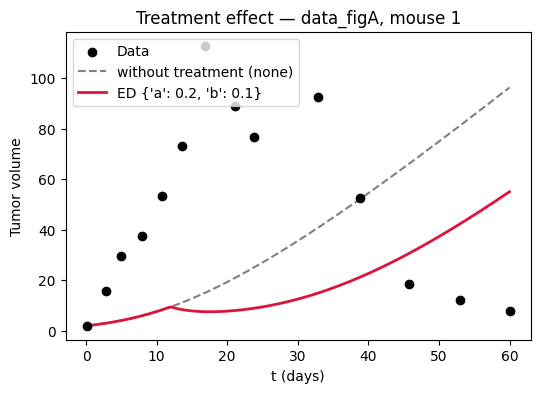

MSE for this guess = 2896.73   (lower is a better fit)


In [8]:
# ----- Input parameters -----
test_group  = list(grouped_data.keys())[0]    # group (folder)
mouse_idx   = 0                               # mouse (0 = first)
test_tmodel = "ED"                            # treatment function
test_params = {"a": 0.2, "b": 0.1}            # ED parameters (a, b)
# ----------------------------

df = grouped_data[test_group]["datasets"][mouse_idx]
t_obs = df["t"].to_numpy(float); v_obs = df["V"].to_numpy(float)
T0 = float(v_obs[0])
t_grid = np.linspace(t_obs.min(), t_obs.max(), 200)

_, v_no_treat = simulate_treatment(t_grid, T0, GROWTH_PARAMS, {}, "none", TREATMENT_DAYS, DOSES)
_, v_treated  = simulate_treatment(t_grid, T0, GROWTH_PARAMS, test_params, test_tmodel, TREATMENT_DAYS, DOSES)
_, v_at_obs   = simulate_treatment(t_obs, T0, GROWTH_PARAMS, test_params, test_tmodel, TREATMENT_DAYS, DOSES)
mse = float(np.mean((v_at_obs - v_obs) ** 2))

plt.figure(figsize=(6, 4))
plt.scatter(t_obs, v_obs, color="black", zorder=3, label="Data")
plt.plot(t_grid, v_no_treat, color="gray", ls="--", label="without treatment (none)")
plt.plot(t_grid, v_treated, color="crimson", lw=2, label=f"{test_tmodel} {test_params}")
plt.xlabel("t (days)"); plt.ylabel("Tumor volume")
plt.title(f"Treatment effect — {test_group}, mouse {mouse_idx+1}")
plt.legend(); plt.show()
print(f"MSE for this guess = {mse:.2f}   (lower is a better fit)")


## 7. Initial guesses and bounds for the treatment parameters

For each treatment function, `get_treatment_spec` defines the parameters to be
estimated, with an initial guess and bounds. The bounds are generic starting
values; if a parameter ends up "at its bound" (see diagnostics) or the fit is
poor, it's worth adjusting them — cell 6.1 helps you find reasonable ranges.

`get_t0_bounds` is identical to the control notebook's: it defines the range
for each mouse's initial volume $T_0$.


In [9]:
def get_treatment_spec(model):
    '''Parameters, initial guess, bounds, and converter for each treatment function.

    Implements 'none' plus the six candidate forms described in Section 5 (ED)
    and Section 7.1 (CD, AccelED, MM, LS, dePR). To add a new function, add
    another `if model == "...":` block here, following the same pattern.
    '''
    if model == "none":          # baseline: no treatment parameters
        return {"n": 0, "names": [], "x0": np.array([]), "bounds": [],
                "to_params": lambda x: {}}

    if model == "ED":            # exponential decay: parameters a, b
        return {"n": 2, "names": ["a", "b"], "x0": np.array([0.2, 0.1]),
                "bounds": [(0.0, 3.0), (0.0, 5.0)],
                "to_params": lambda x: {"a": x[0], "b": x[1]}}

    if model == "CD":             # cumulative dose
        return {"n": 2, "names": ["a", "b"], "x0": np.array([0.1, 0.1]),
                "bounds": [(0.0, 3.0), (0.0, 8.0)],
                "to_params": lambda x: {"a": x[0], "b": x[1]}}

    if model == "AccelED":        # accelerated decay
        return {"n": 2, "names": ["a", "b"], "x0": np.array([0.2, 0.1]),
                "bounds": [(0.0, 3.0), (0.0, 5.0)],
                "to_params": lambda x: {"a": x[0], "b": x[1]}}

    if model == "MM":              # dose saturation (Michaelis-Menten-like)
        return {"n": 2, "names": ["a", "b"], "x0": np.array([0.5, 0.5]),
                "bounds": [(0.0, 5.0), (0.0, 5.0)],
                "to_params": lambda x: {"a": x[0], "b": x[1]}}

    if model == "LS":               # saturation in tumor volume
        return {"n": 2, "names": ["a", "b"], "x0": np.array([0.5, 0.01]),
                "bounds": [(0.0, 5.0), (0.0, 1.0)],
                "to_params": lambda x: {"a": x[0], "b": x[1]}}

    if model == "dePR":              # dose-tumor competition (Hill-type)
        return {"n": 3, "names": ["d", "s", "lam"], "x0": np.array([0.5, 1.0, 1.0]),
                "bounds": [(0.0, 5.0), (1e-6, 50.0), (0.1, 5.0)],
                "to_params": lambda x: {"d": x[0], "s": x[1], "lam": x[2]}}

    raise ValueError(f"Unknown treatment function: {model}")


def get_t0_bounds(volume_arrays):
    '''Initial guess and bounds for each mouse's initial volume T0
    (same logic as in the growth notebook).'''
    guesses, bounds = [], []
    for v in volume_arrays:
        v0 = float(v[0])
        lo = max(1e-6, T0_BOUND_FRACTION_LOW * v0)
        hi = max(v0 * (1.0 + T0_BOUND_BUFFER), T0_BOUND_FRACTION_HIGH * v0)
        guesses.append(v0); bounds.append((lo, hi))
    return np.array(guesses, dtype=float), bounds


### 7.1 Recipe for building the other treatment functions

Each new treatment function requires **three edits**, always in the same places:

1. **Formula** — in `treatment_effect` (Section 5), add a branch
   `elif model == "NAME":` computing that function's contribution to `eff`.
2. **Parameters** — in `get_treatment_spec` (Section 7), add an entry with
   `n` (number of parameters), `names`, `x0` (initial guess), `bounds`,
   and `to_params` (converts the vector into a dictionary).
3. **Registration** — include `"NAME"` in the `TREATMENT_MODELS` list (Section 2).

> ℹ️ **Note:** this version of the notebook already has all six candidate
> functions implemented and registered (in addition to `none`), so you can run
> it as-is. The table and the worked example below are meant as a reference
> for adding a **new** function of your own in the future.

Ready-to-use formulas (with $\Delta = t-\tau$, dose $d$, cumulative dose `cum`,
tumor volume $T$):

| Name | Line in `treatment_effect` | Parameters (spec) |
|---|---|---|
| `CD` | `eff += tp["a"] * cum * math.exp(-tp["b"] * dt)` | `a, b` |
| `AccelED` | `eff += tp["a"] * d * math.exp(-tp["b"] * dt * dt)` | `a, b` |
| `MM` | `eff += (tp["a"] * d) / (1.0 + tp["b"] * d)` | `a, b` |
| `LS` | `eff += (tp["a"] * d) / (1.0 + tp["b"] * T)` | `a, b` |
| `dePR` | `eff += tp["d"] * d**tp["lam"] / (tp["s"]*T**tp["lam"] + d**tp["lam"])` | `d, s, lam` |

The cell below is a **commented template** (it doesn't execute anything),
showing exactly what edits 1 and 2 would look like for the `CD` function. To
enable a brand-new function, copy this pattern into `treatment_effect` and
`get_treatment_spec`, and add its name to `TREATMENT_MODELS`.


In [10]:
# === COMMENTED EXAMPLE: how to add the "CD" (cumulative dose) function ===
#
# 1) In treatment_effect, inside the 'for d, tau ...' loop, after the ED branch:
#
#        elif model == "CD":
#            eff += tp["a"] * cum * math.exp(-tp["b"] * dt)
#
# 2) In get_treatment_spec, before the 'raise':
#
#        if model == "CD":
#            return {"n": 2, "names": ["a", "b"], "x0": np.array([0.1, 0.1]),
#                    "bounds": [(0.0, 3.0), (0.0, 8.0)],
#                    "to_params": lambda x: {"a": x[0], "b": x[1]}}
#
# 3) In Section 2:  TREATMENT_MODELS = ["none", "ED", "CD"]
#
# Nothing to run here: this cell is for reference only.
print("Recipe loaded (reference cell, no effect).")


Recipe loaded (reference cell, no effect).


## 8. Parameter estimation (calibration)

The scheme is the same as in the control notebook. The vector of unknowns is now

$$\theta = [\underbrace{\text{treatment parameters}}_{\text{shared by the group}},\; T_{0,1}, \dots, T_{0,n}]$$

Growth enters as fixed context (`GROWTH_PARAMS`). The objective function
simulates each mouse and sums the squared errors; the `L-BFGS-B` optimizer,
with multiple starting points (*multistart*), minimizes this error. The
optimization helper functions are identical to those in the growth notebook.


In [11]:
def clip_to_bounds(x, bounds):
    '''Clips each entry of x into its corresponding (lo, hi) bound.'''
    x = np.asarray(x, dtype=float).copy()
    for i, (lo, hi) in enumerate(bounds):
        x[i] = np.clip(x[i], lo, hi)
    return x


def sample_param_within_bounds(rng, lo, hi):
    '''Draws a random value within [lo, hi], in log-space if the range is very wide.'''
    if lo <= 0:
        return rng.uniform(lo, hi)
    if hi / max(lo, 1e-12) >= 50:          # very wide range -> sample in log-space
        return float(np.exp(rng.uniform(np.log(lo), np.log(hi))))
    return rng.uniform(lo, hi)


def generate_starting_points(base_x0, bounds, n_starts, rng):
    '''Builds a list of distinct starting points for the multistart optimization:
    the base guess itself, a few scaled versions of it, and random samples
    within the bounds, until we have n_starts unique points.'''
    starts = [clip_to_bounds(base_x0, bounds)]
    base = np.asarray(base_x0, dtype=float)
    for m in [0.5, 0.8, 1.2, 1.5]:
        if len(starts) >= n_starts:
            break
        starts.append(clip_to_bounds(base * m, bounds))
    while len(starts) < n_starts:
        trial = np.array([sample_param_within_bounds(rng, lo, hi) for lo, hi in bounds])
        starts.append(clip_to_bounds(trial, bounds))
    seen, deduped = set(), []
    for x in starts:
        key = tuple(np.round(x, 10))
        if key not in seen:
            seen.add(key); deduped.append(x)
    return deduped


def objective_factory(model, t_list, v_list, n_treat, to_params):
    '''Builds the objective function (mean squared error across all mice) for a
    given treatment function, with the growth term held fixed.'''
    big_penalty = 1e18
    def objective(theta):
        treat = theta[:n_treat]; T0_vec = theta[n_treat:]
        try:
            tp = to_params(treat)
            sqerr_total, n_total = 0.0, 0
            for t_obs, v_obs, T0_i in zip(t_list, v_list, T0_vec):
                if T0_i <= 0 or not np.isfinite(T0_i):
                    return big_penalty
                _, v_hat = simulate_treatment(t_obs, T0_i, GROWTH_PARAMS, tp, model,
                                              TREATMENT_DAYS, DOSES)
                if np.any(~np.isfinite(v_hat)):
                    return big_penalty
                sqerr_total += float(np.sum((v_hat - v_obs) ** 2)); n_total += len(v_obs)
            return sqerr_total / max(n_total, 1)
        except Exception:
            return big_penalty
    return objective


def multistart_optimize(objective, x0, bounds, rng, n_starts):
    '''Runs L-BFGS-B from several starting points and keeps the best result.'''
    starts = generate_starting_points(x0, bounds, n_starts, rng)
    best_res, successful = None, 0
    for start in starts:
        try:
            res = minimize(objective, start, method="L-BFGS-B", bounds=bounds,
                           options={"maxiter": OPT_MAXITER, "maxfun": 5000, "maxls": 30})
        except Exception:
            continue
        if np.isfinite(res.fun):
            successful += int(bool(res.success))
            if best_res is None or res.fun < best_res.fun:
                best_res = res
    if best_res is None:
        raise RuntimeError("All optimization attempts failed.")
    return best_res, len(starts), successful


## 9. Comparison metrics

Identical to the control notebook: information criteria (BIC as the main one,
AIC, AICc) that penalize complexity, and goodness-of-fit metrics (RMSE, MAE,
WAPE/sMAPE, PCC, CCC, ICC). Here, $k$ counts the treatment parameters plus the
$T_0$'s (growth is fixed and does not enter the count).


In [12]:
# --- Information criteria (lower = better; they penalize model complexity) ---
def aic_from_ll(ll, k):            return 2 * k - 2 * ll
def bic_from_ll(ll, k, n):         return k * np.log(n) - 2 * ll
def aicc_from_aic(aic, k, n):
    d = n - k - 1
    return aic + (2 * k * (k + 1)) / d if d > 0 else np.nan

def loglik_gaussian(y, yhat):
    '''Gaussian log-likelihood of the residuals (used to compute AIC/BIC).'''
    resid = np.asarray(y, float) - np.asarray(yhat, float)
    var = max(np.var(resid, ddof=1) if len(resid) > 1 else np.var(resid), 1e-12)
    return -0.5 * np.sum(resid ** 2 / var + np.log(2 * np.pi) + np.log(var))

# --- Goodness-of-fit metrics (in the same units as the data, mm^3) ---
def rmse(y, yhat):
    '''Root Mean Squared Error.'''
    return float(np.sqrt(np.mean((np.asarray(y,float)-np.asarray(yhat,float))**2)))

def mae(y, yhat):
    '''Mean Absolute Error.'''
    return float(np.mean(np.abs(np.asarray(y,float)-np.asarray(yhat,float))))

def wape(y, yhat):
    '''Weighted Absolute Percentage Error: normalized by the total observed volume.'''
    y = np.asarray(y,float); yhat = np.asarray(yhat,float); d = np.sum(np.abs(y))
    return float(100*np.sum(np.abs(y-yhat))/d) if d > 0 else np.nan

def smape(y, yhat):
    '''Symmetric Mean Absolute Percentage Error (can blow up when y and yhat
    are both close to zero — prefer WAPE in that regime).'''
    y = np.asarray(y,float); yhat = np.asarray(yhat,float)
    d = np.where(np.abs(y)+np.abs(yhat) <= 1e-12, 1e-12, np.abs(y)+np.abs(yhat))
    return float(100*np.mean(2*np.abs(y-yhat)/d))

# --- Correlation / agreement metrics (closer to 1 = better agreement) ---
def pcc(y, yhat):
    '''Pearson correlation coefficient (linear association only, ignores bias).'''
    y = np.asarray(y,float); yhat = np.asarray(yhat,float)
    return np.corrcoef(y, yhat)[0, 1] if len(y) >= 2 else np.nan

def ccc(y, yhat):
    '''Lin's Concordance Correlation Coefficient (correlation + bias/scale agreement).'''
    y = np.asarray(y,float); yhat = np.asarray(yhat,float)
    if len(y) < 2: return np.nan
    cov = np.cov(y, yhat, ddof=1)[0, 1]
    d = np.var(y,ddof=1) + np.var(yhat,ddof=1) + (np.mean(y)-np.mean(yhat))**2
    return (2*cov)/d if d > 0 else np.nan

def icc_a1(y, yhat):
    '''Intraclass correlation coefficient (absolute-agreement, one-way ANOVA form).'''
    y = np.asarray(y,float); yhat = np.asarray(yhat,float)
    if len(y) < 2: return np.nan
    X = np.column_stack([y, yhat]); n, k = X.shape
    mr = np.mean(X,1,keepdims=True); mc = np.mean(X,0,keepdims=True); gm = np.mean(X)
    ss_r = k*np.sum((mr-gm)**2); ss_c = n*np.sum((mc-gm)**2); ss_e = np.sum((X-mr-mc+gm)**2)
    df_r, df_c, df_e = n-1, k-1, (n-1)*(k-1)
    if df_r <= 0 or df_e <= 0: return np.nan
    ms_r = ss_r/df_r; ms_c = ss_c/df_c if df_c > 0 else 0.0; ms_e = ss_e/df_e
    den = ms_r + (k-1)*ms_e + (k*(ms_c-ms_e)/n)
    return (ms_r-ms_e)/den if not np.isclose(den, 0) else np.nan

def metrics_from_predictions(y, yhat, k_total):
    '''Bundles all metrics above into a single dict, given k_total estimated parameters.'''
    ll = loglik_gaussian(y, yhat); aic = aic_from_ll(ll, k_total)
    return {"ll": ll, "aic": aic, "aicc": aicc_from_aic(aic, k_total, len(y)),
            "bic": bic_from_ll(ll, k_total, len(y)),
            "mse": float(np.mean((np.asarray(y)-np.asarray(yhat))**2)),
            "rmse": rmse(y,yhat), "mae": mae(y,yhat), "wape": wape(y,yhat),
            "smape": smape(y,yhat), "pcc": pcc(y,yhat), "ccc": ccc(y,yhat),
            "icc": icc_a1(y,yhat), "k_total": k_total}


## 10. Fitting one treatment function to a group

`fit_treatment_model` runs the full cycle for one treatment function: it builds
the $\theta$ vector, optimizes it (multistart, with growth held fixed),
simulates the final fit for each mouse, and computes the metrics.
`build_diagnostics` flags parameters that end up close to their bounds. As in
the control notebook, it accepts `x0_override` and `n_starts` for reuse during
the prediction step.


In [13]:
def is_near_bound(value, bound, rel_tol=BOUNDARY_TOL_REL):
    '''Checks whether a fitted value is within rel_tol of its lower or upper bound.'''
    lo, hi = bound
    if not np.isfinite(value) or hi <= lo: return False
    w = hi - lo
    return (value - lo) <= rel_tol*w or (hi - value) <= rel_tol*w


def build_diagnostics(tp, T0_list, treat_bounds, t0_bounds):
    '''Flags treatment parameters and T0 values that ended up at (or very near)
    their search bounds — usually a sign the data doesn't constrain them well.'''
    notes = []
    for (name, value), bound in zip(tp.items(), treat_bounds):
        if is_near_bound(float(value), bound):
            notes.append(f"{name} at bound [{bound[0]:.4g}, {bound[1]:.4g}]")
    for idx, (val, bound) in enumerate(zip(T0_list, t0_bounds), start=1):
        if is_near_bound(float(val), bound):
            notes.append(f"T0_{idx} at bound [{bound[0]:.4g}, {bound[1]:.4g}]")
    return notes if notes else ["no obvious issues"]


def fit_treatment_model(model, datasets, rng, x0_override=None, n_starts=None):
    '''Full calibration cycle for one treatment function on one group, with the
    growth term G(T) held fixed at GROWTH_PARAMS.'''
    if n_starts is None:
        n_starts = MULTISTART_N_STARTS
    t_list = [df["t"].to_numpy(float) for df in datasets]
    v_list = [df["V"].to_numpy(float) for df in datasets]
    n_mice = len(datasets)

    spec = get_treatment_spec(model)
    n_treat = spec["n"]
    T0_guess, T0_bounds = get_t0_bounds(v_list)
    bounds = list(spec["bounds"]) + T0_bounds
    x0 = np.concatenate([spec["x0"], T0_guess]) if x0_override is None \
         else clip_to_bounds(x0_override, bounds)

    objective = objective_factory(model, t_list, v_list, n_treat, spec["to_params"])
    result, n_used, n_ok = multistart_optimize(objective, x0, bounds, rng, n_starts)
    if not np.isfinite(result.fun):
        raise RuntimeError(f"Optimization failed for treatment function '{model}'.")

    theta_hat = clip_to_bounds(result.x, bounds)
    tp = spec["to_params"](theta_hat[:n_treat])
    T0_hat = theta_hat[n_treat:]

    fits, v_obs_all, v_fit_all = [], [], []
    for i, (t_obs, v_obs, T0_i) in enumerate(zip(t_list, v_list, T0_hat), start=1):
        t_fit, v_fit = simulate_treatment(t_obs, T0_i, GROWTH_PARAMS, tp, model,
                                          TREATMENT_DAYS, DOSES)
        fits.append({"mouse": i, "t_obs": t_obs, "V_obs": v_obs,
                     "t_fit": t_fit, "V_fit": v_fit, "T0": T0_i})
        v_obs_all.append(v_obs); v_fit_all.append(v_fit)

    k_total = n_treat + (n_mice if COUNT_T0_IN_AIC_BIC else 0)
    metrics = metrics_from_predictions(np.concatenate(v_obs_all),
                                       np.concatenate(v_fit_all), k_total)
    diag = build_diagnostics(tp, T0_hat, list(spec["bounds"]), T0_bounds)
    return {"model": model, "params_est": tp, "T0_list": T0_hat, "theta_hat": theta_hat,
            "fits_by_mouse": fits, "metrics": metrics, "diagnostics": diag,
            "optimization": {"objective": float(result.fun), "success": bool(result.success),
                             "n_starts_used": n_used, "n_successful_starts": n_ok}}


def calibrate_treatment_model(model, datasets, seed):
    '''Convenience wrapper: fits one treatment function with a fresh random seed.'''
    fit = fit_treatment_model(model, datasets, np.random.default_rng(seed))
    fit["validation"] = None
    return fit


## 11. Last-point prediction evaluation

Same procedure as the control notebook: the last point of each curve is
removed, the treatment function is calibrated using only the remaining points,
and the removed point is then predicted. For efficiency, the parameters already
found are reused as the initial guess, and validation is only performed for
the `VALIDATION_TOP_K` best models.


In [14]:
def build_validation_datasets(datasets):
    '''For each mouse, builds the training set (without the last point) and the
    hidden point. Returns (None, None) if any mouse lacks enough points.'''
    train, holdout = [], []
    for i, df in enumerate(datasets, start=1):
        if len(df) < 4:
            return None, None
        train.append(df.iloc[:-1].reset_index(drop=True))
        last = df.iloc[-1]
        holdout.append({"mouse": i, "t": float(last["t"]), "V": float(last["V"])})
    return train, holdout


def evaluate_last_point_validation(model, datasets, seed, warm_theta=None):
    '''Refits the treatment function without the last point of each mouse, then
    predicts that point and compares it against the real observed value.'''
    train, holdout = build_validation_datasets(datasets)
    if train is None:
        return None
    n_starts = 2 if warm_theta is not None else MULTISTART_N_STARTS
    fit = fit_treatment_model(model, train, np.random.default_rng(seed),
                              x0_override=warm_theta, n_starts=n_starts)
    y_true, y_pred, per_mouse = [], [], []
    for mf, h in zip(fit["fits_by_mouse"], holdout):
        t_eval = np.append(np.asarray(mf["t_fit"], float), h["t"])
        _, pred = simulate_treatment(t_eval, float(mf["T0"]), GROWTH_PARAMS,
                                     fit["params_est"], model, TREATMENT_DAYS, DOSES)
        v_pred = float(pred[-1])
        y_true.append(h["V"]); y_pred.append(v_pred)
        per_mouse.append({"mouse": h["mouse"], "t_holdout": h["t"],
                          "V_true": h["V"], "V_pred": v_pred,
                          "abs_error": abs(v_pred - h["V"])})
    return {"metrics": {"rmse": rmse(y_true,y_pred), "mae": mae(y_true,y_pred),
                        "wape": wape(y_true,y_pred), "smape": smape(y_true,y_pred),
                        "pcc": pcc(y_true,y_pred), "ccc": ccc(y_true,y_pred),
                        "n_holdout": len(y_true)},
            "per_mouse": per_mouse}


def attach_validation_to_top_models(results, datasets, base_seed, top_k=None):
    '''Runs last-point validation only for the top_k treatment functions with
    the lowest BIC (to save computation time).'''
    if top_k is None:
        top_k = VALIDATION_TOP_K
    if not USE_LAST_POINT_VALIDATION or not top_k or top_k <= 0:
        return results
    ranked = sorted(results, key=lambda x: x["metrics"]["bic"])
    selected = {r["model"] for r in ranked[:min(top_k, len(ranked))]}
    for idx, res in enumerate(results):
        if res["model"] not in selected:
            continue
        try:
            res["validation"] = evaluate_last_point_validation(
                res["model"], datasets, base_seed + 10_000 + idx,
                warm_theta=res.get("theta_hat"))
        except Exception as exc:
            res["validation"] = {"error": str(exc)}
    return results


## 12. Summary table, report, and plot

Same presentation as the control notebook, now comparing treatment functions.
The figure shows, per mouse, the data and the curve for each function; the one
with the lowest BIC is highlighted.


In [15]:
def build_summary_table(results):
    '''Builds a comparison table across all fitted treatment functions, sorted
    by the chosen selection metric (BIC by default), with Delta_BIC / Delta_AICc
    columns added.'''
    rows = []
    for res in results:
        m = res["metrics"]; val = res.get("validation")
        vm = val.get("metrics") if isinstance(val, dict) and "metrics" in val else None
        rows.append({"model": res["model"], "BIC": m["bic"], "AIC": m["aic"],
                     "AICc": m["aicc"], "LogLik": m["ll"], "RMSE": m["rmse"],
                     "MAE": m["mae"], "WAPE (%)": m["wape"], "sMAPE (%)": m["smape"],
                     "PCC": m["pcc"], "CCC": m["ccc"], "ICC": m["icc"],
                     "CV_RMSE": np.nan if vm is None else vm["rmse"],
                     "CV_MAE":  np.nan if vm is None else vm["mae"],
                     "diagnostics": " | ".join(res["diagnostics"])})
    df = pd.DataFrame(rows).sort_values(MODEL_SELECTION_METRIC).reset_index(drop=True)
    df["ΔBIC"] = df["BIC"] - df["BIC"].min()
    df["ΔAICc"] = df["AICc"] - df["AICc"].min(skipna=True)
    return df


def sanitize_filename(name):
    '''Turns a group name into a safe file name (letters, digits, _, ., - only).'''
    return re.sub(r"[^A-Za-z0-9_.-]+", "_", str(name))

def ensure_output_dir(base):
    '''Creates (if needed) and returns the output folder.'''
    out = Path(base) / OUTPUT_DIRNAME; out.mkdir(parents=True, exist_ok=True); return out

def get_layout(n, max_cols=3):
    '''Computes a (rows, cols) grid layout for n subplots.'''
    if n <= 0: return 1, 1
    c = min(max_cols, n); return math.ceil(n / c), c


def format_group_report(group_name, filepaths, datasets, results, summary_df):
    '''Builds the full plain-text report for one treated group: file list, the
    fixed growth term, the treatment schedule, the comparison table, the best
    function, and per-function parameters/diagnostics/validation.'''
    L = ["="*90, f"RESULTS FOR TREATED GROUP: {group_name}", "="*90, "",
         f"Fixed growth term: {GROWTH_MODEL} {GROWTH_PARAMS}",
         f"Schedule: days={TREATMENT_DAYS} doses={DOSES}", "", "FILES"]
    for i, (fp, df) in enumerate(zip(filepaths, datasets), start=1):
        L.append(f"  Mouse {i}: {Path(fp).name} | n={len(df)} | "
                 f"t∈[{df['t'].min():.2f},{df['t'].max():.2f}] | "
                 f"V∈[{df['V'].min():.4g},{df['V'].max():.4g}]")
    L += ["", "TREATMENT FUNCTION COMPARISON (sorted by BIC)",
          summary_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"), ""]
    L.append(f"BEST FUNCTION BY {MODEL_SELECTION_METRIC}: {summary_df.iloc[0]['model']}")
    L += ["", "PARAMETERS AND DIAGNOSTICS"]
    for res in sorted(results, key=lambda x: x["metrics"]["bic"]):
        L.append(f"\n[{res['model']}]  objective={res['optimization']['objective']:.6g}")
        if res["params_est"]:
            for name, value in res["params_est"].items():
                L.append(f"  {name:>5s} = {value:.6g}")
        else:
            L.append("  (no treatment parameters)")
        for i, T0 in enumerate(res["T0_list"], start=1):
            L.append(f"  T0_mouse_{i} = {T0:.6g}")
        for note in res["diagnostics"]:
            L.append(f"    - {note}")
        val = res.get("validation")
        if isinstance(val, dict) and "metrics" in val:
            vm = val["metrics"]
            L.append(f"  LAST-POINT PREDICTION: RMSE={vm['rmse']:.4g} "
                     f"MAE={vm['mae']:.4g} WAPE={vm['wape']:.2f}% CCC={vm['ccc']:.3f}")
            for r in val["per_mouse"]:
                L.append(f"    Mouse {r['mouse']}: t={r['t_holdout']:.1f} "
                         f"true={r['V_true']:.4g} predicted={r['V_pred']:.4g} "
                         f"error={r['abs_error']:.4g}")
    return "\n".join(L)


def build_parameter_table(results):
    '''Builds a table with the estimated treatment parameters and per-mouse T0
    for every function.'''
    rows = []
    for res in results:
        base = {"model": res["model"]}
        base.update(res["params_est"])
        for i, v in enumerate(res["T0_list"], start=1):
            base[f"T0_mouse_{i}"] = v
        rows.append(base)
    return pd.DataFrame(rows)


def write_reports(output_dir, group_name, filepaths, datasets, results, summary_df):
    '''Saves the text report and the two CSV tables (summary + parameters) to disk.'''
    sg = sanitize_filename(group_name)
    text = format_group_report(group_name, filepaths, datasets, results, summary_df)
    (output_dir / f"report_treatment_{sg}.txt").write_text(text, encoding="utf-8")
    summary_df.to_csv(output_dir / f"summary_treatment_{sg}.csv", index=False)
    build_parameter_table(results).to_csv(output_dir / f"parameters_treatment_{sg}.csv", index=False)
    return text


def plot_fits(datasets, results, group_name, output_name):
    '''Plots one panel per mouse: observed data as black dots, and the fitted
    curve of every treatment function overlaid, with the BIC winner drawn thicker.'''
    rs = sorted(results, key=lambda x: x["metrics"]["bic"])
    best = rs[0]["model"]; n = len(datasets)
    n_rows, n_cols = get_layout(n, 3)
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(max(4.8*n_cols,6.0), max(3.8*n_rows+1.2,4.8)),
                             sharey=True, squeeze=False)
    axes = axes.ravel()
    legend = {}
    for j, ax in enumerate(axes):
        if j >= n:
            ax.axis("off"); continue
        df = datasets[j]
        ax.scatter(df["t"], df["V"], color="black", s=35, zorder=3, label="Data")
        for res in rs:
            mdl = res["model"]; fit = res["fits_by_mouse"][j]
            line, = ax.plot(fit["t_fit"], fit["V_fit"],
                            lw=2.8 if mdl==best else 1.6,
                            alpha=1.0 if mdl==best else 0.7, label=mdl)
            legend.setdefault(mdl, line)
        ax.set_title(f"Mouse {j+1}"); ax.set_xlabel("t (days)")
        ax.grid(True, ls="--", alpha=0.35)
    axes[0].set_ylabel("Tumor volume")
    fig.suptitle(f"Treatment — {group_name} | growth: {GROWTH_MODEL} | "
                 f"best: {best} | BIC={rs[0]['metrics']['bic']:.2f}", y=0.995)
    fig.legend(list(legend.values()), list(legend.keys()), loc="upper center",
               ncol=min(7, len(legend)), frameon=True, bbox_to_anchor=(0.5, 0.955))
    plt.tight_layout(rect=[0, 0, 1, 0.90])
    plt.savefig(output_name, dpi=300, bbox_inches="tight")
    plt.show(); plt.close(fig)


## 13. Run

Runs the procedure for the groups defined in `GROUPS_TO_RUN`: calibrates each
treatment function against the fixed growth term, validates the prediction of
the best ones, prints the report, saves the files, and displays the figure.
The results end up in `calibration_outputs_treatment/`.


Output folder: C:\Users\power\OneDrive\Bureau\CESI\Cancer site\notebooks_calibracao_NBA\calibration_outputs_treatment



Calibrating treatment (data_figA): 100%|██████████| 7/7 [07:02<00:00, 60.32s/model]


RESULTS FOR TREATED GROUP: data_figA

Fixed growth term: linear {'r': 2.49816, 'f': 14.2442}
Schedule: days=[12.0] doses=[1.0]

FILES
  Mouse 1: data_frosberg19_fig3A_hIL2_NOG_CART_1.csv | n=14 | t∈[0.10,60.00] | V∈[1.987,112.9]
  Mouse 2: data_frosberg19_fig3A_hIL2_NOG_CART_2.csv | n=13 | t∈[0.10,54.04] | V∈[1.987,84.68]
  Mouse 3: data_frosberg19_fig3A_hIL2_NOG_CART_3.csv | n=13 | t∈[1.39,54.04] | V∈[8.158,55.11]
  Mouse 4: data_frosberg19_fig3A_hIL2_NOG_CART_4.csv | n=12 | t∈[1.19,53.25] | V∈[6.402,55.46]

TREATMENT FUNCTION COMPARISON (sorted by BIC)
  model      BIC      AIC     AICc    LogLik    RMSE     MAE  WAPE (%)  sMAPE (%)     PCC     CCC     ICC  CV_RMSE  CV_MAE                                                                                           diagnostics    ΔBIC   ΔAICc
     MM 522.1246 510.4172 512.2838 -249.2086 29.0806 20.8206   54.9171    65.4126  0.0875  0.0482  0.0490  27.0161 26.9636                                         T0_1 at bound [0.1987, 7.947] | T0_

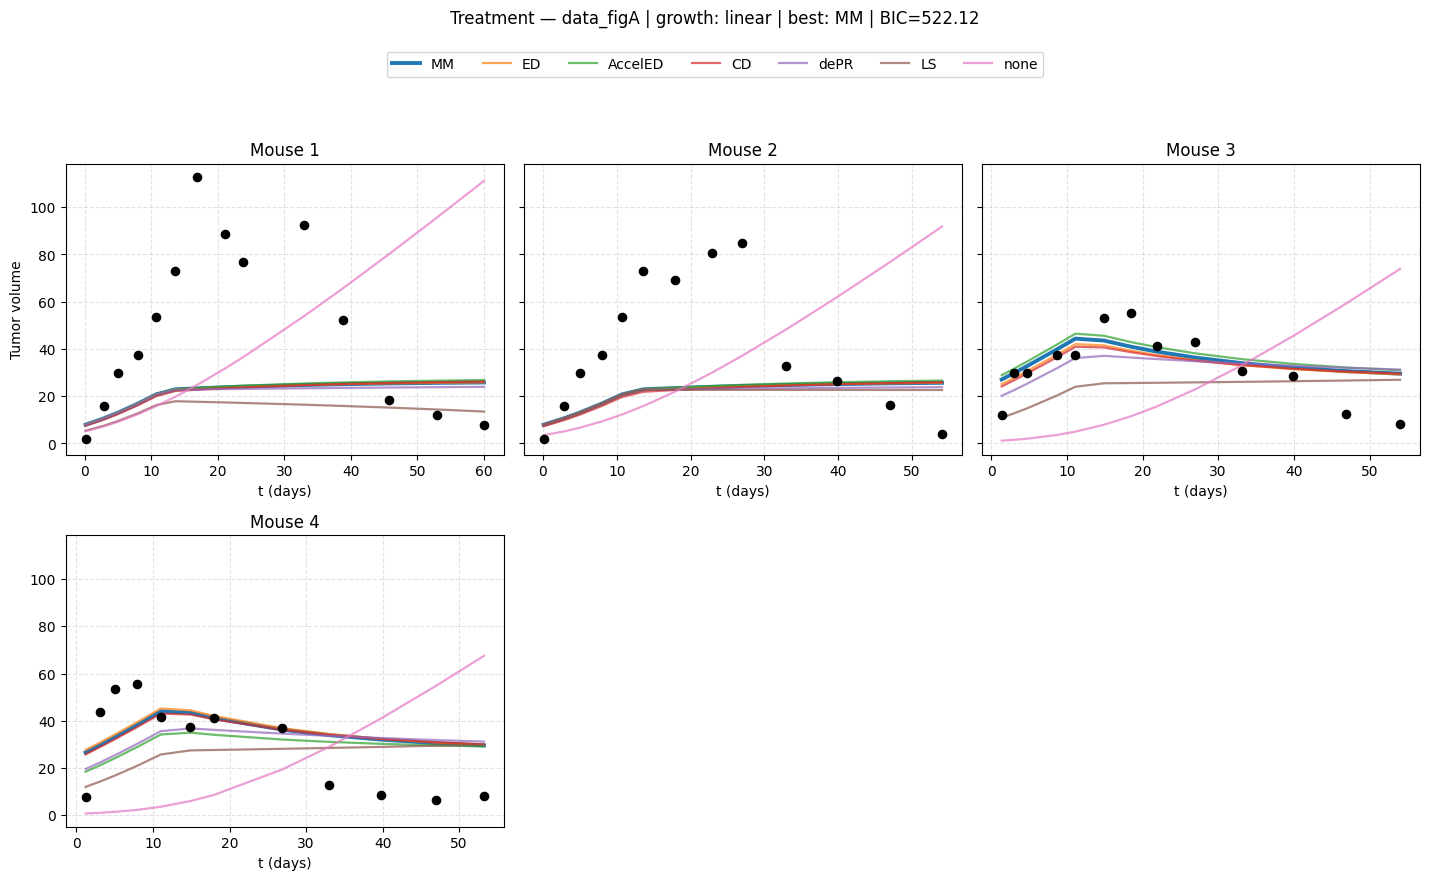


Files saved for group 'data_figA'.



Calibrating treatment (data_figB): 100%|██████████| 7/7 [01:41<00:00, 14.50s/model]


RESULTS FOR TREATED GROUP: data_figB

Fixed growth term: linear {'r': 2.49816, 'f': 14.2442}
Schedule: days=[12.0] doses=[1.0]

FILES
  Mouse 1: data_frosberg19_fig3B_hIL2_NOG_CART_1.csv | n=18 | t∈[0.79,61.01] | V∈[0.0276,163]
  Mouse 2: data_frosberg19_fig3B_hIL2_NOG_CART_2.csv | n=18 | t∈[0.79,61.01] | V∈[0.0276,118.8]
  Mouse 3: data_frosberg19_fig3B_hIL2_NOG_CART_3.csv | n=18 | t∈[0.79,60.90] | V∈[0.0276,95.67]

TREATMENT FUNCTION COMPARISON (sorted by BIC)
  model      BIC      AIC     AICc    LogLik    RMSE     MAE  WAPE (%)  sMAPE (%)     PCC     CCC     ICC  CV_RMSE  CV_MAE                                                                                                                                                              diagnostics    ΔBIC  ΔAICc
   none 605.3910 599.4241 599.9041 -296.7120 56.1144 43.5267   99.1774   142.1357 -0.4636 -0.1921 -0.1949  51.5236 51.4576                                                                                                        

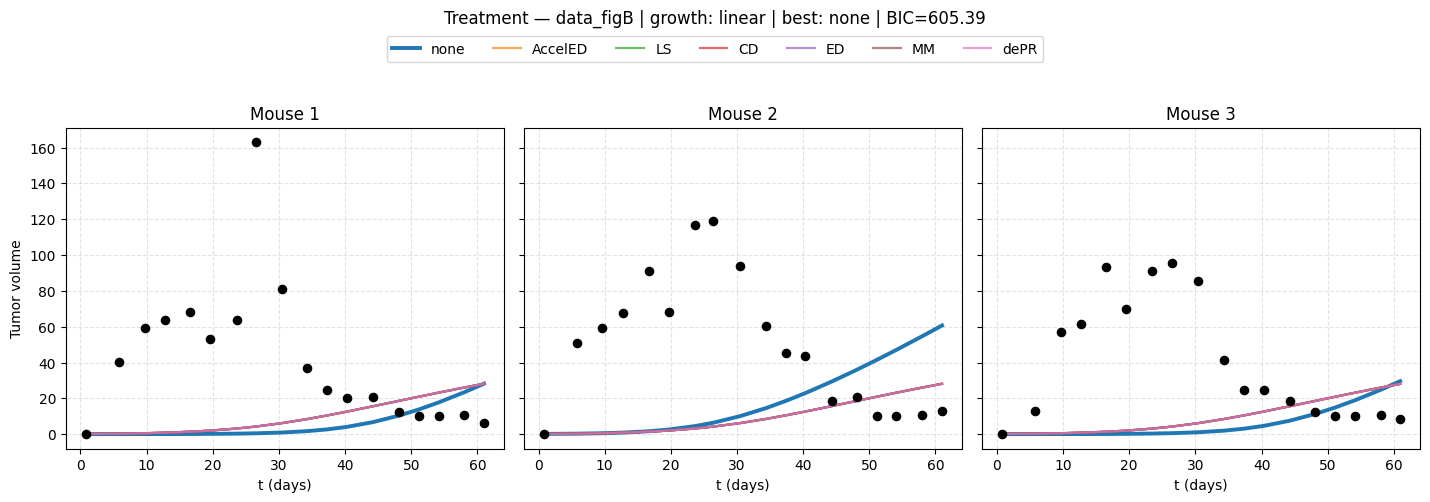


Files saved for group 'data_figB'.



Calibrating treatment (data_figC): 100%|██████████| 7/7 [02:24<00:00, 20.60s/model]


RESULTS FOR TREATED GROUP: data_figC

Fixed growth term: linear {'r': 2.49816, 'f': 14.2442}
Schedule: days=[12.0] doses=[1.0]

FILES
  Mouse 1: data_frosberg19_fig3C_hIL2_NOG_CART_1.csv | n=8 | t∈[12.29,67.28] | V∈[0.5089,63.61]
  Mouse 2: data_frosberg19_fig3C_hIL2_NOG_CART_2.csv | n=13 | t∈[12.29,103.17] | V∈[0.5089,50.89]
  Mouse 3: data_frosberg19_fig3C_hIL2_NOG_CART_3.csv | n=8 | t∈[12.29,67.26] | V∈[0.5089,50.89]
  Mouse 4: data_frosberg19_fig3C_hIL2_NOG_CART_4.csv | n=13 | t∈[12.29,102.98] | V∈[0.5089,33.08]

TREATMENT FUNCTION COMPARISON (sorted by BIC)
  model      BIC      AIC     AICc    LogLik    RMSE     MAE  WAPE (%)  sMAPE (%)     PCC     CCC     ICC  CV_RMSE  CV_MAE                                                                                                                                                                                            diagnostics    ΔBIC   ΔAICc
     LS 394.2054 383.7794 386.1794 -185.8897 20.1753 15.5982   64.6894    77.6247 -0.0323 -0.

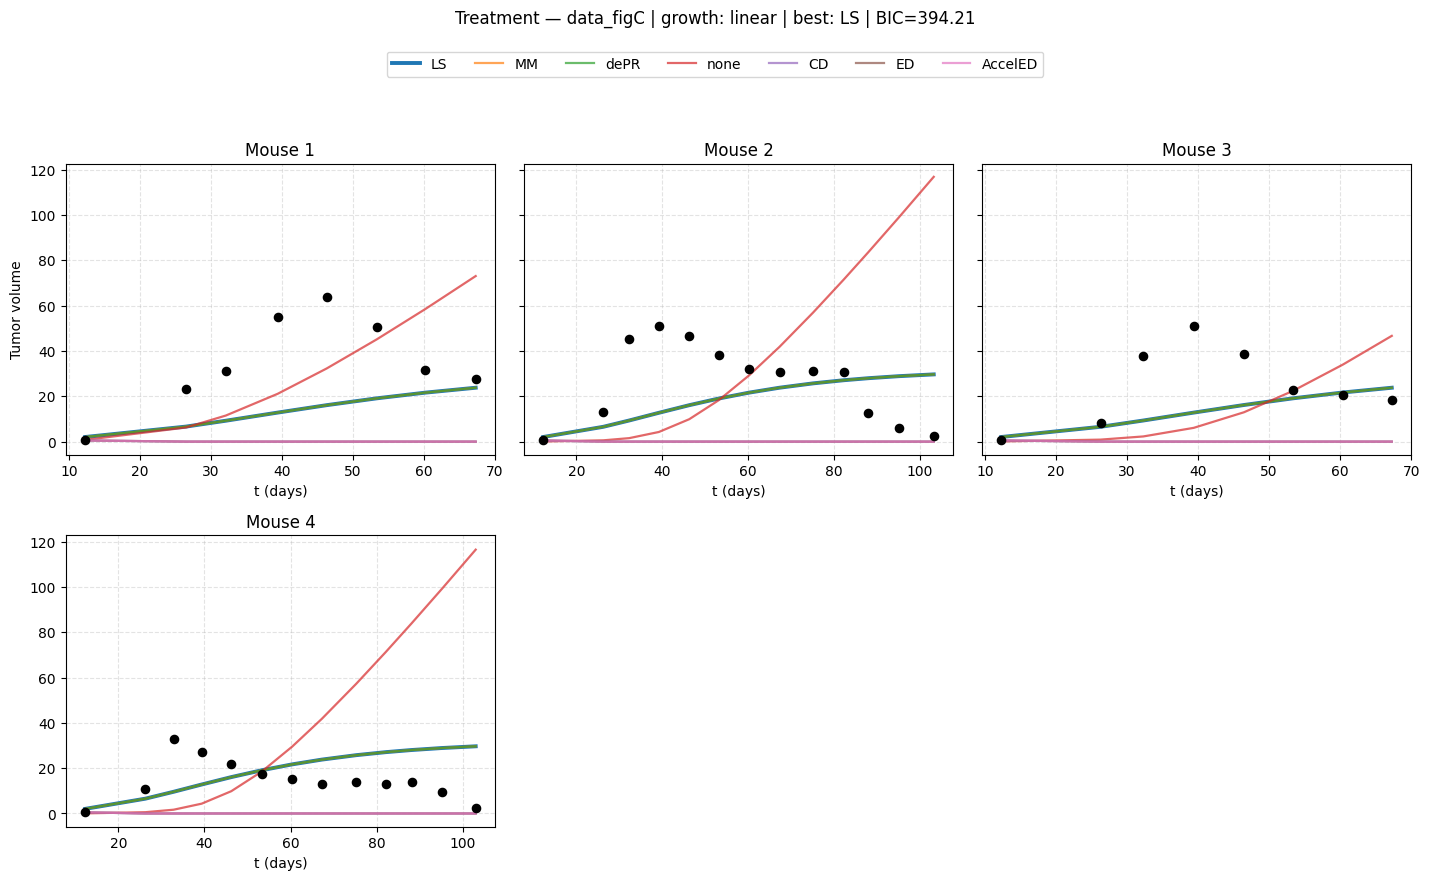


Files saved for group 'data_figC'.



Calibrating treatment (data_figD): 100%|██████████| 7/7 [02:40<00:00, 22.99s/model]


RESULTS FOR TREATED GROUP: data_figD

Fixed growth term: linear {'r': 2.49816, 'f': 14.2442}
Schedule: days=[12.0] doses=[1.0]

FILES
  Mouse 1: data_frosberg19_fig3D_hIL2_NOG_CART_1.csv | n=25 | t∈[12.92,184.06] | V∈[0.8271,79.82]
  Mouse 2: data_frosberg19_fig3D_hIL2_NOG_CART_2.csv | n=25 | t∈[13.12,184.06] | V∈[0.09336,41.69]
  Mouse 3: data_frosberg19_fig3D_hIL2_NOG_CART_3.csv | n=19 | t∈[12.92,150.15] | V∈[0.7007,21.9]
  Mouse 4: data_frosberg19_fig3D_hIL2_NOG_CART_4.csv | n=20 | t∈[12.92,150.15] | V∈[0.994,10.75]

TREATMENT FUNCTION COMPARISON (sorted by BIC)
  model       BIC       AIC      AICc    LogLik     RMSE     MAE  WAPE (%)  sMAPE (%)     PCC     CCC     ICC  CV_RMSE  CV_MAE                                                                                                                                                        diagnostics     ΔBIC    ΔAICc
     MM  781.5579  766.6261  767.6505 -377.3130  16.7855 12.1452   70.7592    81.9271  0.3478  0.2284  0.2304  21.8988 2

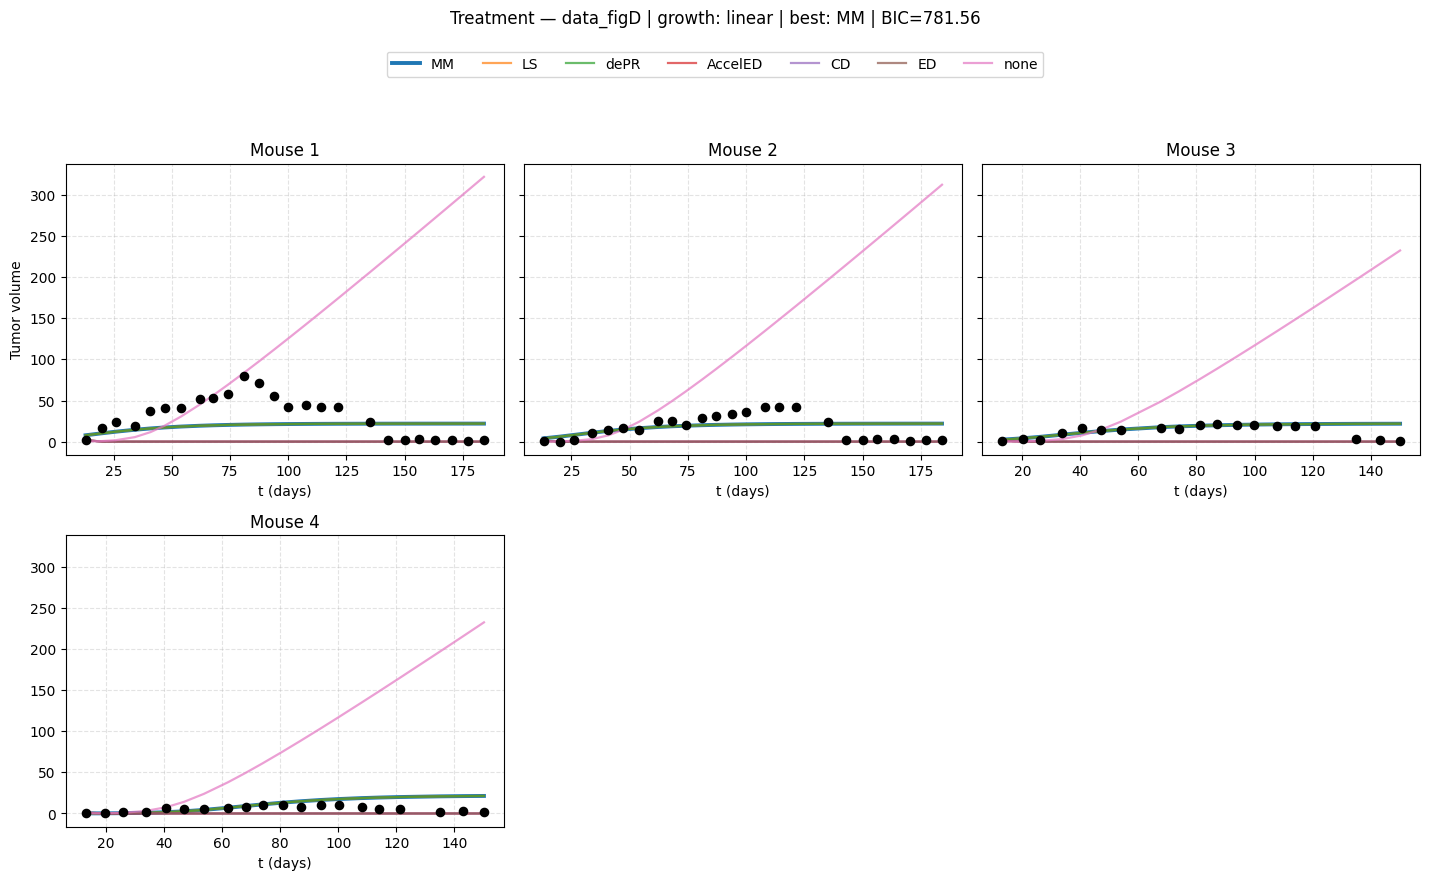


Files saved for group 'data_figD'.

Done.


In [16]:
output_dir = ensure_output_dir(data_root)
print(f"Output folder: {output_dir}\n")
all_results = {}

if GROUPS_TO_RUN is None:
    items = list(grouped_data.items())
else:
    items = [(g, grouped_data[g]) for g in GROUPS_TO_RUN if g in grouped_data]

for gi, (group_name, gd) in enumerate(items):
    filepaths, datasets = gd["filepaths"], gd["datasets"]
    results = []
    for mi, model in enumerate(tqdm(TREATMENT_MODELS,
                                    desc=f"Calibrating treatment ({group_name})", unit="model")):
        try:
            results.append(calibrate_treatment_model(model, datasets,
                                                     seed=RANDOM_SEED + 1000*gi + 100*mi))
        except Exception as e:
            print(f"[WARNING] {group_name} | {model} failed: {e}")
    if not results:
        print(f"[WARNING] No calibration succeeded for {group_name}"); continue

    results = attach_validation_to_top_models(results, datasets, RANDOM_SEED + 1000*gi)
    summary_df = build_summary_table(results)
    print(format_group_report(group_name, filepaths, datasets, results, summary_df))

    plot_fits(datasets, results, group_name,
              output_dir / f"treatment_calibration_{sanitize_filename(group_name)}.png")
    write_reports(output_dir, group_name, filepaths, datasets, results, summary_df)
    all_results[group_name] = {"results": results, "summary": summary_df}
    print(f"\nFiles saved for group '{group_name}'.\n")

print("Done.")


## 14. Using this with treated data

1. First calibrate growth on the control group (growth notebook) and note the
   winning law and its parameters (`parameters_*.csv` file).
2. Fill in `GROWTH_MODEL` and `GROWTH_PARAMS` in Section 2 with those values.
3. Organize the treated data using the same folder/file convention, and set
   `FILE_GLOB` to the corresponding label (for example, `..._NOG_CART_*.csv`).
4. Define the treatment schedule in `TREATMENT_DAYS` and `DOSES`.
5. Run the notebook in order.

Notes:

- The `none` model (no treatment) serves as a baseline reference. If it wins by
  BIC, the data does not support a treatment term among the functions tested.
- The parameter bounds in `get_treatment_spec` are generic starting points. If a
  parameter ends up "at its bound" (diagnostics) or the fit is poor, adjust the
  bounds; cell 6.1 helps you find reasonable ranges.
- Growth is kept fixed in order to isolate the treatment effect. To also
  re-estimate the growth parameters, they would need to be included in the
  $\theta$ vector — a possible extension, outside the scope of this version.

## 15. Interpreting the results

- The lowest BIC indicates the preferred treatment function; $\Delta\text{BIC} < 2$
  indicates practical equivalence (in that case, also check AICc, RMSE, and the
  correlation metrics).
- Diagnostics: parameters at their bound suggest that the data doesn't
  constrain that function well, or that the bounds need adjusting.
- Compare `RMSE` (fit) with `CV_RMSE` (prediction): describing the past well
  does not guarantee good prediction.
- To compare groups (control, CAR-T, CAR-T + IL-2), gather the best function
  and its parameters from each group; growth, common to the tumor, comes from
  the control fit.
